# DiffAlign diversity investigation

Goal: understand why first-time generation and inpainting produce near-identical precursors per product. Sweep `diffusion_steps` and temperature scaling across a panel of pharmaceutically relevant molecules and measure:
- unique / valid ratios (post-dedup, post-RDKit parse)
- mean pairwise Morgan-Tanimoto similarity (diversity proxy — lower = more diverse)
- wall-clock per cell
- presence of known textbook precursors among the top-k

This notebook is **read-only** w.r.t. the deployed app — no defaults get changed here. Findings feed a separate discussion before we touch `inference.py:65` or the HTML defaults.

## Environment
Run from the `diffalign-10` conda env (per `CLAUDE.md`):
```bash
conda activate diffalign-10
jupyter lab experiments/diversity_investigation.ipynb
```

In [1]:
import os, sys, time, json, itertools
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

# Add repo root so DiffAlign imports resolve when this notebook lives in experiments/
REPO_ROOT = Path('.').resolve().parents[0] if Path('.').resolve().name == 'experiments' else Path('.').resolve()
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / 'DiffAlign'))
print('Repo root:', REPO_ROOT)

Repo root: /Users/laabidn1/RetroLab


In [2]:
from diffalign.inference import (
    get_model_and_cfg, _ensure_transition_model, _decode_samples,
    smiles_to_dense_data, BOND_TYPES, device,
)
from diffalign.utils.mol import get_cano_smiles_with_atom_mapping

model, cfg = get_model_and_cfg()
print('Model loaded on', device)
print('atom_types:', cfg.dataset.atom_types)

loading model from /Users/laabidn1/RetroLab/DiffAlign/checkpoints/epoch760.pt
Model loaded on cpu
atom_types: ['none', 'O', 'C', 'N', 'I', 'Cl', 'Si', 'F', 'Br', 'N+1', 'O-1', 'S', 'B', 'N-1', 'Zn+1', 'Cu', 'Sn', 'P+1', 'Mg+1', 'C-1', 'P', 'S+1', 'S-1', 'Se', 'Zn', 'Mg', 'U', 'Au', 'SuNo']


## Product panel

Covers aromatics (aspirin, ibuprofen, paracetamol), fused heterocycles (caffeine), chirality (menthol), and a simple aromatic control (benzene). Known textbook precursors are listed per product for the plausibility check.

In [3]:
# Canonicalised SMILES help the plausibility check use exact string comparison.
def canon(s):
    m = Chem.MolFromSmiles(s)
    return Chem.MolToSmiles(m, canonical=True) if m is not None else None

PRODUCTS = [
    {
        'name': 'aspirin',
        'smiles': canon('CC(=O)Oc1ccccc1C(=O)O'),
        # salicylic acid + acetic anhydride (or acetyl chloride)
        'known_precursors': [canon('OC(=O)c1ccccc1O'), canon('CC(=O)OC(C)=O')],
    },
    {
        'name': 'ibuprofen',
        'smiles': canon('CC(C)Cc1ccc(C(C)C(=O)O)cc1'),
        # isobutylbenzene + methylpropanoyl intermediate (simplified)
        'known_precursors': [canon('CC(C)Cc1ccccc1'), canon('CC(C(=O)O)Br')],
    },
    {
        'name': 'paracetamol',
        'smiles': canon('CC(=O)Nc1ccc(O)cc1'),
        # 4-aminophenol + acetic anhydride
        'known_precursors': [canon('Nc1ccc(O)cc1'), canon('CC(=O)OC(C)=O')],
    },
    {
        'name': 'caffeine',
        'smiles': canon('Cn1cnc2n(C)c(=O)n(C)c(=O)c12'),
        # theobromine + methylating agent (MeI) — classical route
        'known_precursors': [canon('Cn1cnc2[nH]c(=O)n(C)c(=O)c12'), canon('CI')],
    },
    {
        'name': 'menthol',
        'smiles': canon('CC(C)[C@@H]1CC[C@@H](C)C[C@H]1O'),
        'known_precursors': [canon('CC(C)[C@@H]1CC[C@@H](C)CC1=O')],  # menthone
    },
    {
        'name': 'benzene',
        'smiles': canon('c1ccccc1'),
        'known_precursors': [],  # control — no classical one-step retro
    },
]
for p in PRODUCTS:
    print(f"{p['name']:<13} {p['smiles']}  known={len(p['known_precursors'])}")

aspirin       CC(=O)Oc1ccccc1C(=O)O  known=2
ibuprofen     CC(C)Cc1ccc(C(C)C(=O)O)cc1  known=2
paracetamol   CC(=O)Nc1ccc(O)cc1  known=2
caffeine      Cn1c(=O)c2c(ncn2C)n(C)c1=O  known=2
menthol       CC(C)[C@@H]1CC[C@@H](C)C[C@H]1O  known=1
benzene       c1ccccc1  known=0


## Sampling helper — returns RAW (undeduplicated) SMILES

We bypass `_decode_samples`'s dedup step so we can see the true n_unique / n_raw ratio and compute pairwise diversity over the actual set the model produced.

In [4]:
def sample_raw(product_smiles, n_samples, diffusion_steps, temp_node=1.0, temp_edge=1.0):
    """Return (raw_reactant_smiles_list, wall_clock_seconds).
    
    raw_reactant_smiles_list has length n_samples, one SMILES per sample (may
    repeat).
    """
    _ensure_transition_model(model, cfg, diffusion_steps)
    # Mutate temperature in place — sampling.py reads cfg.diffusion.temperature_scaling_*
    # at every denoising step, so this takes effect immediately.
    cfg.diffusion.temperature_scaling_node = float(temp_node)
    cfg.diffusion.temperature_scaling_edge = float(temp_edge)

    dense_data = smiles_to_dense_data(
        max_nodes_more_than_product=cfg.dataset.nb_rct_dummy_nodes,
        product_smiles=product_smiles,
        atom_types=cfg.dataset.atom_types,
        bond_types=BOND_TYPES,
        with_explicit_h=cfg.dataset.with_explicit_h,
        with_formal_charge=cfg.dataset.with_formal_charge,
        add_supernode_edges=cfg.dataset.add_supernode_edges,
        canonicalize_molecule=cfg.dataset.canonicalize_molecule,
        permute_mols=cfg.dataset.permute_mols,
    ).to_device(device)

    t0 = time.time()
    with torch.inference_mode():
        final = model.sample_for_condition(
            dense_data=dense_data, n_samples=n_samples,
            inpaint_node_idx=None, inpaint_edge_idx=None, device=device,
        )
    dt = time.time() - t0

    rxn_strs, _ = get_cano_smiles_with_atom_mapping(
        final.X, final.E, cfg.dataset.atom_types, BOND_TYPES,
    )
    raw = [s.split('>>')[0] if '>>' in s else s for s in rxn_strs]
    return raw, dt

## Diversity metrics

In [5]:
def morgan_fp(smi, radius=2, nbits=2048):
    m = Chem.MolFromSmiles(smi)
    if m is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(m, radius, nbits)

def pairwise_tanimoto(smiles_list):
    fps = [morgan_fp(s) for s in smiles_list]
    fps = [fp for fp in fps if fp is not None]
    if len(fps) < 2:
        return np.nan, 0
    sims = [DataStructs.TanimotoSimilarity(fps[i], fps[j])
            for i in range(len(fps)) for j in range(i+1, len(fps))]
    return float(np.mean(sims)), len(fps)

def summarize(raw, wall_clock, known_precursors):
    # Canonicalise for fair uniqueness / matching
    canonical = []
    n_invalid = 0
    for s in raw:
        parts = s.split('.')
        parsed = [Chem.MolFromSmiles(p) for p in parts]
        if any(m is None for m in parsed):
            n_invalid += 1
            canonical.append(None)
        else:
            canonical.append('.'.join(sorted(Chem.MolToSmiles(m, canonical=True) for m in parsed)))

    valid_canon = [c for c in canonical if c is not None]
    unique_valid = sorted(set(valid_canon))
    mean_tan, n_compared = pairwise_tanimoto(unique_valid)

    # Plausibility: does any known precursor appear as a component of any sample?
    known_set = set(p for p in known_precursors if p)
    found_known = []
    for c in unique_valid:
        for comp in c.split('.'):
            if comp in known_set:
                found_known.append(comp)
                break

    return {
        'n_raw':             len(raw),
        'n_valid':           len(valid_canon),
        'n_invalid':         n_invalid,
        'n_unique':          len(unique_valid),
        'valid_ratio':       len(valid_canon) / max(1, len(raw)),
        'unique_ratio':      len(unique_valid) / max(1, len(raw)),
        'mean_tanimoto':     mean_tan,
        'n_fp_compared':     n_compared,
        'wall_clock_s':      round(wall_clock, 2),
        'n_known_found':     len(set(found_known)),
        'known_found':       sorted(set(found_known)),
    }

## Sweep grid

Cell count = `products × steps × temps = 6 × 5 × 3 = 90` cells × 20 samples each. On CPU with 50-step cells, this can run 20-60 min — tweak `N_SAMPLES` or trim the grid if that's too slow on first pass.

Constraint: `diffusion_steps` must divide 500 (the model's hardcoded T).

In [6]:
STEP_COUNTS = [1, 5, 10, 25, 50]
TEMPS = [
    (1.0, 1.0),   # default — no temperature scaling
    (1.2, 1.2),   # moderate softening
    (1.5, 1.5),   # strong softening
]
N_SAMPLES = 20

CACHE_PATH = Path('experiments') / 'diversity_cache.json'
CACHE_PATH.parent.mkdir(exist_ok=True)

def cache_key(name, steps, tn, te, n):
    return f'{name}__s{steps}__tn{tn}__te{te}__n{n}'

cache = {}
if CACHE_PATH.exists():
    cache = json.loads(CACHE_PATH.read_text())
print('cached cells:', len(cache))

cached cells: 0


In [7]:
rows = []
for product in PRODUCTS:
    for steps, (tn, te) in itertools.product(STEP_COUNTS, TEMPS):
        key = cache_key(product['name'], steps, tn, te, N_SAMPLES)
        if key in cache:
            row = cache[key]
        else:
            print(f"Running {product['name']:<12} steps={steps:<3} temp=({tn},{te}) ...", end=' ', flush=True)
            raw, dt = sample_raw(product['smiles'], N_SAMPLES, steps, tn, te)
            stats = summarize(raw, dt, product['known_precursors'])
            row = {
                'product':     product['name'],
                'smiles':      product['smiles'],
                'steps':       steps,
                'temp_node':   tn,
                'temp_edge':   te,
                **stats,
            }
            cache[key] = row
            CACHE_PATH.write_text(json.dumps(cache, indent=2))
            print(f"wall={dt:.1f}s unique={stats['unique_ratio']:.2f} tan={stats['mean_tanimoto']}")
        rows.append(row)

df = pd.DataFrame(rows)
df.to_csv(Path('experiments') / 'diversity_results.csv', index=False)
df.head()

Running aspirin      steps=1   temp=(1.0,1.0) ... wall=0.9s unique=0.20 tan=0.8295855379188711
Running aspirin      steps=1   temp=(1.2,1.2) ... wall=0.9s unique=0.20 tan=0.8295855379188711
Running aspirin      steps=1   temp=(1.5,1.5) ... wall=0.8s unique=0.10 tan=0.9583333333333334
Running aspirin      steps=5   temp=(1.0,1.0) ... wall=3.8s unique=0.15 tan=0.7837301587301587
Running aspirin      steps=5   temp=(1.2,1.2) ... wall=5.5s unique=0.25 tan=0.8042989417989418
Running aspirin      steps=5   temp=(1.5,1.5) ... wall=4.7s unique=0.15 tan=0.7802028218694885
Running aspirin      steps=10  temp=(1.0,1.0) ... wall=8.8s unique=0.05 tan=nan
Running aspirin      steps=10  temp=(1.2,1.2) ... wall=7.9s unique=0.10 tan=0.9583333333333334
Running aspirin      steps=10  temp=(1.5,1.5) ... wall=8.1s unique=0.15 tan=0.7802028218694885
Running aspirin      steps=25  temp=(1.0,1.0) ... wall=19.6s unique=0.05 tan=nan
Running aspirin      steps=25  temp=(1.2,1.2) ... wall=19.5s unique=0.10 tan=0.

,product,smiles,steps,temp_node,temp_edge,n_raw,n_valid,n_invalid,n_unique,valid_ratio,unique_ratio,mean_tanimoto,n_fp_compared,wall_clock_s,n_known_found,known_found
0,aspirin,CC(=O)Oc1ccccc1C(=O)O,1,1.0,1.0,20,20,0,4,1.00,0.20,0.829586,4,0.91,1,[O=C(O)c1ccccc1O]
1,aspirin,CC(=O)Oc1ccccc1C(=O)O,1,1.2,1.2,20,20,0,4,1.00,0.20,0.829586,4,0.90,1,[O=C(O)c1ccccc1O]
2,aspirin,CC(=O)Oc1ccccc1C(=O)O,1,1.5,1.5,20,20,0,2,1.00,0.10,0.958333,2,0.79,1,[O=C(O)c1ccccc1O]
3,aspirin,CC(=O)Oc1ccccc1C(=O)O,5,1.0,1.0,20,19,1,3,0.95,0.15,0.783730,3,3.81,1,[O=C(O)c1ccccc1O]
4,aspirin,CC(=O)Oc1ccccc1C(=O)O,5,1.2,1.2,20,18,2,5,0.90,0.25,0.804299,5,5.53,1,[O=C(O)c1ccccc1O]


## Visualisations

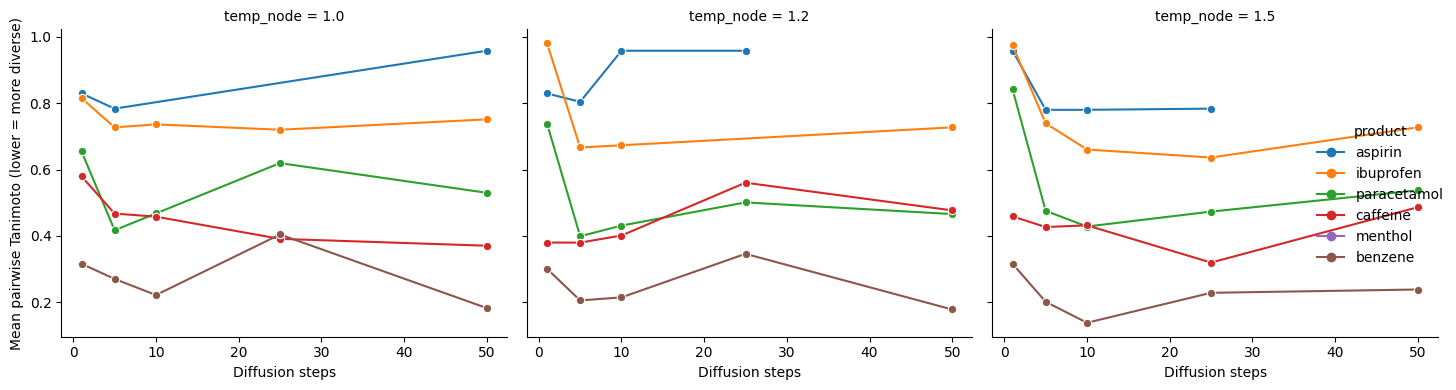

In [8]:
# Mean pairwise Tanimoto vs. diffusion steps, one line per product, one facet per temperature
g = sns.relplot(
    data=df, kind='line', x='steps', y='mean_tanimoto',
    hue='product', col='temp_node', marker='o', height=4, aspect=1.1,
)
g.set_axis_labels('Diffusion steps', 'Mean pairwise Tanimoto (lower = more diverse)')
g.set_titles('temp_node = {col_name}')
plt.tight_layout()

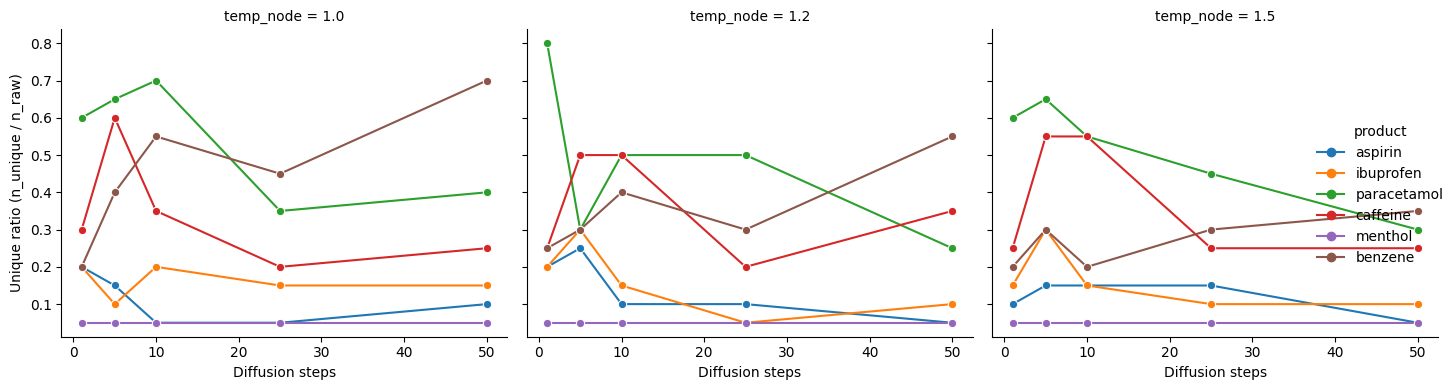

In [9]:
# Unique ratio: how much dedup hurts us at each (steps, temp)
g = sns.relplot(
    data=df, kind='line', x='steps', y='unique_ratio',
    hue='product', col='temp_node', marker='o', height=4, aspect=1.1,
)
g.set_axis_labels('Diffusion steps', 'Unique ratio (n_unique / n_raw)')
g.set_titles('temp_node = {col_name}')
plt.tight_layout()

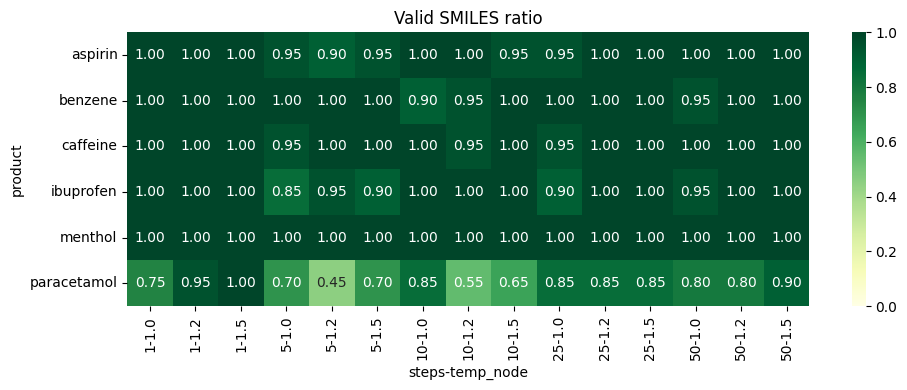

In [10]:
# Valid ratio heatmap — how often does the model produce RDKit-parseable SMILES?
pivot = df.pivot_table(index='product', columns=['steps', 'temp_node'], values='valid_ratio')
plt.figure(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGn', vmin=0, vmax=1)
plt.title('Valid SMILES ratio')
plt.tight_layout()

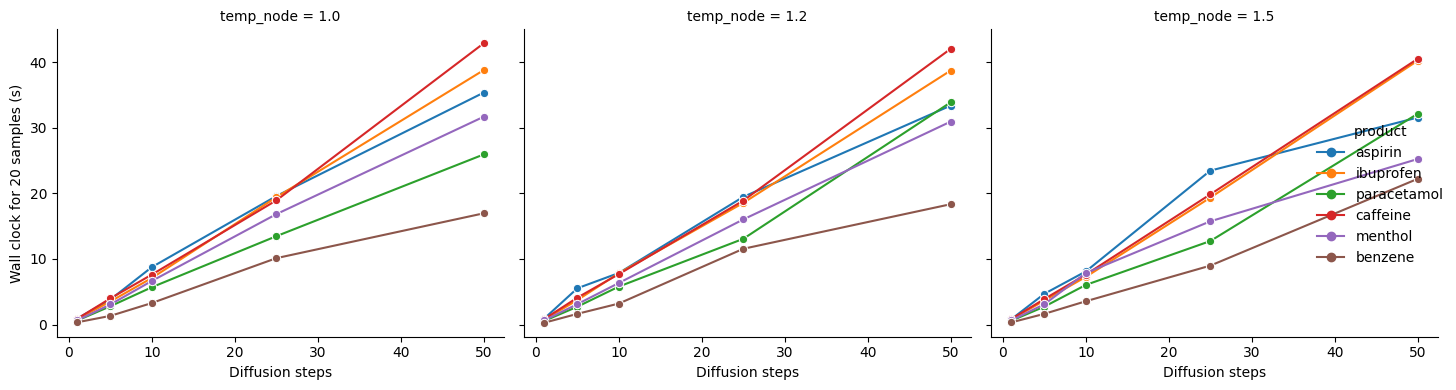

In [11]:
# Wall-clock scaling — sanity check that raising defaults stays under the 600s gunicorn timeout
g = sns.relplot(
    data=df, kind='line', x='steps', y='wall_clock_s',
    hue='product', col='temp_node', marker='o', height=4, aspect=1.1,
)
g.set_axis_labels('Diffusion steps', f'Wall clock for {N_SAMPLES} samples (s)')
plt.tight_layout()

## Plausible-precursor coverage

For each product with known textbook precursors, count how often the model surfaces at least one of them.

In [12]:
coverage = df[df['product'] != 'benzene'].groupby(['product', 'steps', 'temp_node'])['n_known_found'].sum().reset_index()
coverage.pivot_table(index='product', columns=['steps', 'temp_node'], values='n_known_found', fill_value=0)

steps         1              5              10             25             50  \
temp_node    1.0  1.2  1.5  1.0  1.2  1.5  1.0  1.2  1.5  1.0  1.2  1.5  1.0   
product                                                                        
aspirin      1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0   
caffeine     1.0  1.0  1.0  2.0  2.0  2.0  2.0  2.0  2.0  1.0  1.0  1.0  1.0   
ibuprofen    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
menthol      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
paracetamol  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   

steps                  
temp_node    1.2  1.5  
product                
aspirin      1.0  1.0  
caffeine     1.0  1.0  
ibuprofen    0.0  0.0  
menthol      0.0  0.0  
paracetamol  0.0  0.0

## Notes

_Fill this in after running the sweep. Suggested questions to answer:_

- At what `diffusion_steps` value does `mean_tanimoto` drop below ~0.6 across most products?
- Does temperature scaling give meaningful additional diversity, or does it just hurt validity?
- Which products are hardest (caffeine? menthol?) — is it a diversity issue or a validity issue?
- For the `steps` value that looks best on diversity, what's the wall-clock for 20 samples? Does it fit under 600s even for the slowest product?

Once these are answered, we can discuss raising the `diffusion_steps_eval` default in `DiffAlign/diffalign/inference.py:65` and the HTML input default in `wsgi.py:539`.